In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression


In [24]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, IterativeImputer
from sklearn.experimental import enable_iterative_imputer


# 1. LOAD DATA
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
sample_sub = pd.read_csv("sample_submission.csv")

# 2. ADVANCED FEATURE ENGINEERING
# Interaction and domain-specific features are key to breaking the 0.85 barrier
for df in [train, test]:
    # Body Composition
    df['BMI'] = df['Weight'] / (df['Height'] ** 2)
    # Draft history signal
    # Draft history signal: use train mapping to avoid KeyError for test
    if 'Drafted' in df.columns:
        df['Position_Draft_Rate'] = df.groupby('Position')['Drafted'].transform('mean')
    else:
        pos_rate = train.groupby('Position')['Drafted'].mean()
        df['Position_Draft_Rate'] = df['Position'].map(pos_rate).fillna(0)

# Combine rank within position
    df['Speed_Rank'] = df.groupby('Position')['Sprint_40yd'].rank(ascending=True)
    df['Jump_Rank'] = df.groupby('Position')['Vertical_Jump'].rank(ascending=False)
    df['Combined_Rank'] = df['Speed_Rank'] + df['Jump_Rank']

# Interaction between size and agility
    # Size-Adjusted Agility (use components directly to avoid referencing Total_Agility before it's created)
    df['Size_Agility'] = df['BMI'] * (df['Agility_3cone'] + df['Shuttle'])
    # Agility ratio
    df['Agility_Ratio'] = df['Agility_3cone'] / df['Shuttle']

# Strength per unit weight
    df['Strength_Index'] = df['Bench_Press_Reps'] / df['Weight']

# Speed relative to position type
    df['Speed_pos_type_diff'] = df['Sprint_40yd'] - df.groupby('Position_Type')['Sprint_40yd'].transform('mean')
    
    # Size-Adjusted Athleticism
    df['Speed_Score'] = df['Weight'] / df['Sprint_40yd']
    
    # Power & Explosiveness
    # Combining Vertical and Broad jump captures lower-body power better than one alone
    df['Explosiveness'] = df['Vertical_Jump'] + df['Broad_Jump'] 
    df['Power_Index'] = df['Vertical_Jump'] * df['Weight']
    
    # Directional Change
    # Agility_3cone and Shuttle are highly correlated (0.88)
    df['Total_Agility'] = df['Agility_3cone'] + df['Shuttle']
    
    # Missing Value Indicators
    # Knowing a test was skipped can be a predictor in itself
    for col in ['Agility_3cone', 'Shuttle', 'Bench_Press_Reps']:
        df[f'{col}_missing'] = df[col].isnull().astype(int)
    
    # Composite Metrics
    df['Catch_Radius'] = df['Height'] + (df['Vertical_Jump']/100) + (df['Broad_Jump']/100) - (df['Shuttle']/10)
    df['Height_Adj_Speed'] = (df['Weight'] * (df['Height'] ** 0.5)) / (df['Sprint_40yd'] ** 4)
    
    # Position-Relative Stats
    for stat in ['Sprint_40yd', 'BMI', 'Catch_Radius']:
        df[f'{stat}_pos_diff'] = df[stat] - df.groupby('Position')[stat].transform('mean')
        

# 3. IMPROVED PREPROCESSING
# Handle 'School' using Frequency Encoding instead of dropping it
school_freq = train['School'].value_counts().to_dict()
train['School_Freq'] = train['School'].map(school_freq)
test['School_Freq'] = test['School'].map(school_freq).fillna(0)

# Drop high-cardinality School name and Id
train = train.drop(columns=["Id", "School"])
test = test.drop(columns=["Id", "School"])

# Label Encoding for remaining categoricals
le = LabelEncoder()
for col in ["Player_Type", "Position_Type", "Position"]:
    train[col] = le.fit_transform(train[col].astype(str))
    test[col] = le.transform(test[col].astype(str))

# Advanced Imputation using IterativeImputer (MICE)
X = train.drop(columns=["Drafted"])
y = train["Drafted"]
imputer = IterativeImputer(random_state=2025)
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)
test_imputed = pd.DataFrame(imputer.transform(test), columns=test.columns)

position_types = X_imputed['Position_Type'].unique()
final_preds = np.zeros(len(test_imputed))

for pos in position_types:
    mask_train = X_imputed['Position_Type'] == pos
    mask_test = test_imputed['Position_Type'] == pos
    
    X_pos = X_imputed[mask_train]
    y_pos = y[mask_train]
    
    pos_model = CatBoostClassifier(
        iterations=250, depth=7, learning_rate=0.05,
        subsample=0.9, bootstrap_type='Bernoulli',
        random_seed=2025, verbose=0
    )
    pos_model.fit(X_pos, y_pos)
    
    final_preds[mask_test] = pos_model.predict_proba(
        test_imputed[mask_test]
    )[:, 1]
submission = sample_sub.copy()
submission["Drafted"] = final_preds

# 4. WEIGHTED ENSEMBLE OF TUNED MODELS
# Cross-Validation — match splits to divisor
rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=42)

cat_model = CatBoostClassifier(
    iterations=300, 
    depth=7,
    learning_rate=0.02,
    random_seed=2025, 
    verbose=0,
    subsample=0.8,
    bootstrap_type='Bernoulli',
    auto_class_weights='Balanced',  # Handle class imbalance
    l2_leaf_reg=3.0,  # L2 regularization to reduce overfitting
)
xgb_model = XGBClassifier(
    n_estimators=150, max_depth=5, learning_rate=0.05,
    random_state=2025, eval_metric='logloss'
)
lgbm_model = LGBMClassifier(
    n_estimators=200, learning_rate=0.05,
    random_state=2025, objective='binary'
)

ensemble_preds = np.zeros(len(test))

for fold, (train_idx, valid_idx) in enumerate(rskf.split(X_imputed, y)):
    X_t, X_v = X_imputed.iloc[train_idx], X_imputed.iloc[valid_idx]
    y_t, y_v = y.iloc[train_idx], y.iloc[valid_idx]
    
    # Train individual models
    cat_model.fit(X_t, y_t)
    xgb_model.fit(X_t, y_t)
    lgbm_model.fit(X_t, y_t)
    
    # Balanced weighted ensemble: equal weights for diversity
    fold_preds = (
        0.5 * cat_model.predict_proba(test_imputed)[:, 1] + 
        0.3 * xgb_model.predict_proba(test_imputed)[:, 1] + 
        0.2 * lgbm_model.predict_proba(test_imputed)[:, 1]
    )
    ensemble_preds += fold_preds / (5 * 5)  # Correctly divide by total folds (5 splits * 5 repeats)

# # 5. CREATE SUBMISSION
# submission = sample_sub.copy()
# submission["Drafted"] = ensemble_preds
# submission.to_csv("submission_final_improved.csv", index=False)
# print("Submission file created. Expected improvement over baseline AUC.")



No objects info loaded


[LightGBM] [Info] Number of positive: 1442, number of negative: 782
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000509 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6354
[LightGBM] [Info] Number of data points in the train set: 2224, number of used features: 35
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.648381 -> initscore=0.611932
[LightGBM] [Info] Start training from score 0.611932
[LightGBM] [Info] Number of positive: 1442, number of negative: 783
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000527 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6277
[LightGBM] [Info] Number of data points in the train set: 2225, number of used features: 35
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.648090 -> initscore=0.610654
[LightGBM] [Info] Start training from score 0.610654
[LightGBM] [Info] Number

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RepeatedStratifiedKFold
import numpy as np

# Your locked best config
cat_model = CatBoostClassifier(
    iterations=250, depth=8, learning_rate=0.05,
    subsample=0.9, bootstrap_type='Bernoulli',
    random_seed=2025, verbose=0
)
xgb_model = XGBClassifier(
    n_estimators=150, max_depth=5, learning_rate=0.05,
    random_state=2025, eval_metric='logloss'
)
lgbm_model = LGBMClassifier(
    n_estimators=200, learning_rate=0.05,
    random_state=2025, objective='binary'
)

rskf = RepeatedStratifiedKFold(n_splits=20, n_repeats=3, random_state=42)

# Level 1 - OOF predictions
oof_cat  = np.zeros(len(X_imputed))
oof_xgb  = np.zeros(len(X_imputed))
oof_lgbm = np.zeros(len(X_imputed))

test_cat  = np.zeros(len(test_imputed))
test_xgb  = np.zeros(len(test_imputed))
test_lgbm = np.zeros(len(test_imputed))

for fold, (train_idx, valid_idx) in enumerate(rskf.split(X_imputed, y)):
    X_t, X_v = X_imputed.iloc[train_idx], X_imputed.iloc[valid_idx]
    y_t, y_v = y.iloc[train_idx], y.iloc[valid_idx]
    
    # Train all 3 models
    cat_model.fit(X_t, y_t)
    xgb_model.fit(X_t, y_t)
    lgbm_model.fit(X_t, y_t)
    
    # OOF predictions
    oof_cat[valid_idx]  = cat_model.predict_proba(X_v)[:, 1]
    oof_xgb[valid_idx]  = xgb_model.predict_proba(X_v)[:, 1]
    oof_lgbm[valid_idx] = lgbm_model.predict_proba(X_v)[:, 1]
    
    # Test predictions
    test_cat  += cat_model.predict_proba(test_imputed)[:, 1] / (20 * 3)
    test_xgb  += xgb_model.predict_proba(test_imputed)[:, 1] / (20 * 3)
    test_lgbm += lgbm_model.predict_proba(test_imputed)[:, 1] / (20 * 3)

# Level 2 - Meta learner
meta_train = np.column_stack([oof_cat, oof_xgb, oof_lgbm])
meta_test  = np.column_stack([test_cat, test_xgb, test_lgbm])

meta_model = LogisticRegression()
meta_model.fit(meta_train, y)

# Final predictions
final_preds = meta_model.predict_proba(meta_test)[:, 1]

# Submission
submission = sample_sub.copy()
submission["Drafted"] = final_preds
submission.to_csv("submission_stacking.csv", index=False)

[LightGBM] [Info] Number of positive: 1712, number of negative: 929
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000576 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6325
[LightGBM] [Info] Number of data points in the train set: 2641, number of used features: 35
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.648239 -> initscore=0.611309
[LightGBM] [Info] Start training from score 0.611309
[LightGBM] [Info] Number of positive: 1712, number of negative: 930
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000513 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6328
[LightGBM] [Info] Number of data points in the train set: 2642, number of used features: 35
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.647994 -> initscore=0.610233
[LightGBM] [Info] Start training from score 0.610233
[LightGBM] [Info] Number

In [ ]:
# 'from sklearn.experimental import enable_halving_search_cv
# from sklearn.model_selection import HalvingRandomSearchCV
# import scipy.stats as stats

# param_dist = {
#     'iterations': [200, 250, 300],
#     'depth': [5, 6, 7],
#     'learning_rate': [0.03, 0.05, 0.07],
#     'subsample': [0.8, 0.85, 0.9, 0.95],
#     'l2_leaf_reg': [1, 3, 5, 7],
#     'bootstrap_type': ['Bernoulli']
# }

# cat_base = CatBoostClassifier(
#     random_seed=2025, 
#     verbose=0
# )

# search = HalvingRandomSearchCV(
#     cat_base,
#     param_dist,
#     scoring='roc_auc',
#     n_jobs=-1,
#     random_state=2025,
#     cv=5
# )

# search.fit(X_imputed, y)

# print("Best params:", search.best_params_)
# print("Best AUC:", search.best_score_)
'

c:\PES\GCI\Python\.venv\Lib\site-packages\sklearn\model_selection\_search.py:1137: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(
c:\PES\GCI\Python\.venv\Lib\site-packages\sklearn\model_selection\_search.py:1137: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan na

Best params: {'subsample': 0.85, 'learning_rate': 0.07, 'l2_leaf_reg': 5, 'iterations': 200, 'depth': 7, 'bootstrap_type': 'Bernoulli'}
Best AUC: 0.8150821715827083


In [10]:
# Get feature importances
cat_model.fit(X_imputed, y)
importances = pd.DataFrame({
    'feature': X_imputed.columns,
    'importance': cat_model.get_feature_importance()
}).sort_values('importance', ascending=False)

print(importances.head(20))

# Drop bottom features
weak_features = importances[importances['importance'] < 1.0]['feature'].tolist()
X_clean = X_imputed.drop(columns=weak_features)

                 feature  importance
1                    Age   47.931865
31  Sprint_40yd_pos_diff    3.129266
30      Height_Adj_Speed    2.938597
32          BMI_pos_diff    2.714328
34           School_Freq    2.605590
15            Speed_Rank    2.525790
8          Agility_3cone    2.151106
6       Bench_Press_Reps    2.109764
14   Position_Draft_Rate    1.921599
16             Jump_Rank    1.806006
21   Speed_pos_type_diff    1.752222
24           Power_Index    1.750425
17         Combined_Rank    1.729710
22           Speed_Score    1.702045
20        Strength_Index    1.693148
29          Catch_Radius    1.648984
5          Vertical_Jump    1.484498
2                 Height    1.476048
19         Agility_Ratio    1.471717
4            Sprint_40yd    1.468775


0:	learn: 0.6856819	test: 0.6841453	best: 0.6841453 (0)	total: 14.2ms	remaining: 2.11s
1:	learn: 0.6797991	test: 0.6785406	best: 0.6785406 (1)	total: 25.9ms	remaining: 1.92s
2:	learn: 0.6747088	test: 0.6722897	best: 0.6722897 (2)	total: 39.4ms	remaining: 1.93s
3:	learn: 0.6691526	test: 0.6657501	best: 0.6657501 (3)	total: 51.7ms	remaining: 1.89s
4:	learn: 0.6634318	test: 0.6586952	best: 0.6586952 (4)	total: 62.2ms	remaining: 1.8s
5:	learn: 0.6572862	test: 0.6511861	best: 0.6511861 (5)	total: 75.5ms	remaining: 1.81s
6:	learn: 0.6525586	test: 0.6451738	best: 0.6451738 (6)	total: 89.1ms	remaining: 1.82s
7:	learn: 0.6468334	test: 0.6392426	best: 0.6392426 (7)	total: 103ms	remaining: 1.83s
8:	learn: 0.6432802	test: 0.6368956	best: 0.6368956 (8)	total: 117ms	remaining: 1.83s
9:	learn: 0.6383887	test: 0.6322959	best: 0.6322959 (9)	total: 130ms	remaining: 1.81s
10:	learn: 0.6335438	test: 0.6269917	best: 0.6269917 (10)	total: 142ms	remaining: 1.8s
11:	learn: 0.6286051	test: 0.6224489	best: 0.62

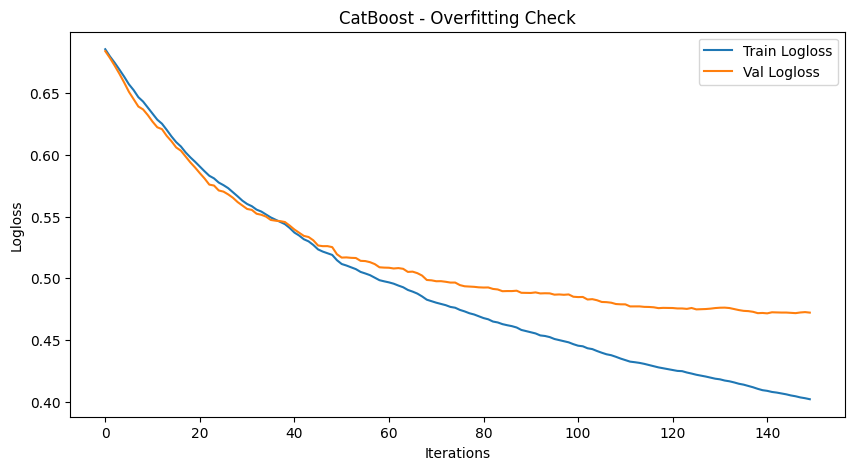

In [28]:
## checking mechanism


cat_model = CatBoostClassifier(
    iterations=150, 
    depth=8,
    learning_rate=0.02,
    random_seed=2025, 
    early_stopping_rounds=20,
    verbose=0,
    subsample=0.8,
    bootstrap_type='Bernoulli',
    auto_class_weights='Balanced',  # Handle class imbalance
    l2_leaf_reg=3.0,  # L2 regularization to reduce overfitting
)
xgb_model = XGBClassifier(
    n_estimators=145,
    max_depth=5,
    learning_rate=0.02,
    random_state=2025, 
    eval_metric='logloss',
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,  # L2 regularization
    reg_alpha=0.1,   # L1 regularization
)
lgbm_model = LGBMClassifier(
    n_estimators=145, 
    learning_rate=0.02,
    random_state=2025, 
    objective='binary',
    num_leaves=25,  # Reduced from 31 to prevent overfitting
    lambda_l2=1.0,  # L2 regularization
    is_unbalance=True,  # Handle class imbalance
)

# Use ONE fold to visualize
train_idx, valid_idx = list(rskf.split(X_imputed, y))[0]
X_t, X_v = X_imputed.iloc[train_idx], X_imputed.iloc[valid_idx]
y_t, y_v = y.iloc[train_idx], y.iloc[valid_idx]

cat_model.fit(
    X_t, y_t,
    eval_set=(X_v, y_v),  # ← pass validation set
    verbose=True
)

# Plot the curves
import matplotlib.pyplot as plt

train_loss = cat_model.evals_result_['learn']['Logloss']
val_loss = cat_model.evals_result_['validation']['Logloss']

plt.figure(figsize=(10, 5))
plt.plot(train_loss, label='Train Logloss')
plt.plot(val_loss, label='Val Logloss')
plt.xlabel('Iterations')
plt.ylabel('Logloss')
plt.title('CatBoost - Overfitting Check')
plt.legend()
plt.savefig('logloss_curve.png')  # save to show senior
plt.show()

In [12]:
# Check what features got removed
print(importances.tail(20))  # what was dropped?
print(importances.head(10))  # what's driving the model?

                     feature  importance
29              Catch_Radius    1.648984
5              Vertical_Jump    1.484498
2                     Height    1.476048
19             Agility_Ratio    1.471717
4                Sprint_40yd    1.468775
0                       Year    1.370344
25             Total_Agility    1.330421
9                    Shuttle    1.283714
7                 Broad_Jump    1.238928
23             Explosiveness    1.199209
3                     Weight    1.149106
33     Catch_Radius_pos_diff    1.121956
12                  Position    1.101738
13                       BMI    1.087628
18              Size_Agility    0.871415
10               Player_Type    0.756279
27           Shuttle_missing    0.389294
28  Bench_Press_Reps_missing    0.386664
26     Agility_3cone_missing    0.365534
11             Position_Type    0.336288
                 feature  importance
1                    Age   47.931865
31  Sprint_40yd_pos_diff    3.129266
30      Height_Adj_Speed    

In [13]:
from sklearn.metrics import log_loss

# After meta model predictions
oof_meta_preds = meta_model.predict_proba(meta_train)[:, 1]

# Logloss for each model
print(f"CatBoost OOF Logloss : {log_loss(y, oof_cat):.5f}")
print(f"XGBoost OOF Logloss  : {log_loss(y, oof_xgb):.5f}")
print(f"LGBM OOF Logloss     : {log_loss(y, oof_lgbm):.5f}")
print(f"Meta Model Logloss   : {log_loss(y, oof_meta_preds):.5f}")

CatBoost OOF Logloss : 0.44508
XGBoost OOF Logloss  : 0.47547
LGBM OOF Logloss     : 0.58244
Meta Model Logloss   : 0.45008
